https://www.cvxportfolio.com/en/stable/hello_world.html

20 March 2024

In [1]:
import cvxportfolio as cvx
# import yfinance
import matplotlib.pyplot as plt

In [2]:
gamma = 2.5
kappa = 0.05

In [3]:
objective = cvx.ReturnsForecast() - gamma * (
	cvx.FullCovariance() + kappa * cvx.RiskForecastError()
) - cvx.StocksTransactionCost()

In [4]:
constraints = [cvx.LeverageLimit(3)]

In [5]:
policy = cvx.MultiPeriodOptimization(objective, constraints, planning_horizon=2)

In [6]:
simulator = cvx.StockMarketSimulator(
    ['AAPL', 'AMZN', 'UBER', 'ZM', 'CVX', 'TSLA', 'GM', 'ABNB', 'CTAS', 'GOOG'])

Updating data....

 cvxportfolio.YahooFinance('CTAS').data contains NaNs. You may want to inspect it. If you want, you can delete the data file in ~/cvxportfolio_data/YahooFinance to force re-download from the start.


.

 cvxportfolio.YahooFinance('CVX').data contains NaNs. You may want to inspect it. If you want, you can delete the data file in ~/cvxportfolio_data/YahooFinance to force re-download from the start.


.....


In [7]:
results = simulator.backtest_many([policy, cvx.Uniform()], start_time='2020-01-01')

In [8]:
# print statistics result of the backtest
print("\n# MULTI-PERIOD OPTIMIZATION\n", results[0])
print("\n# UNIFORM ALLOCATION:\n", results[1])


# MULTI-PERIOD OPTIMIZATION
 
#################################################################
Universe size                                                  11
Initial timestamp                       2020-01-02 14:30:00+00:00
Final timestamp                         2024-03-19 13:30:00+00:00
Number of periods                                            1060
Initial value (USDOLLAR)                                1.000e+06
Final value (USDOLLAR)                                  3.129e+06
Profit (USDOLLAR)                                       2.129e+06
                                                                 
Avg. return (annualized)                                    33.0%
Volatility (annualized)                                     34.3%
Avg. excess return (annualized)                             31.1%
Avg. active return (annualized)                             31.1%
Excess volatility (annualized)                              34.4%
Active volatility (annualized)               

~/micromamba/envs/finance/lib/python3.12/site-packages/cvxportfolio/result.py:862: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show() # pragma: no cover


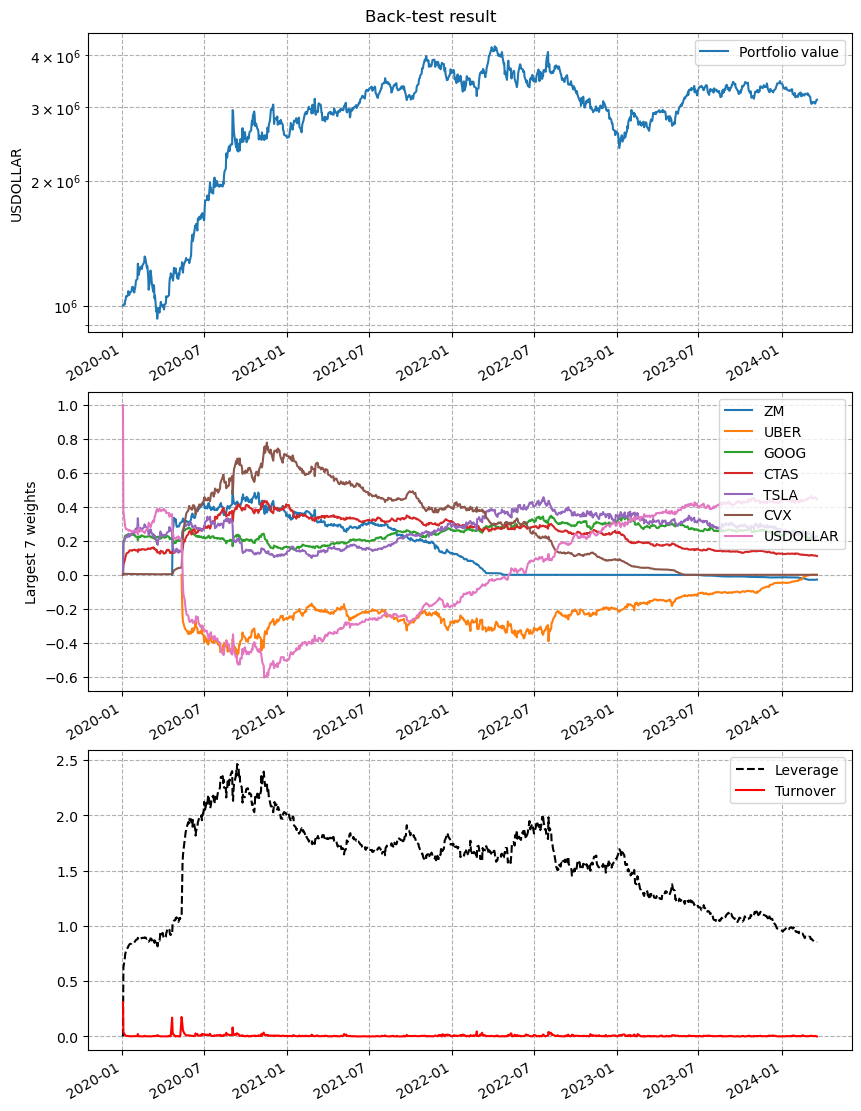

In [9]:
# plot value and weights of the portfolio in time for MPO
results[0].plot()